In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to work dir
# to import my modules
dir_work ='/nfs/home/svu/e1498138/localgit/FEWNEW/work/'

os.chdir(dir_work)
sys.path.insert(0, dir_work)

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")

def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    return transformed

def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    params = np.asarray(params)
    u = np.zeros_like(params)

    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])

    return u


Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...


In [2]:
dir_scratch='/scratch/e1498138/'
savepath = dir_scratch+'paris1/'


In [3]:
sampler_7 = parismc.Sampler.load_state(savepath+'int_3mth_snr32_7/sampler_state.pkl')
sampler_8 = parismc.Sampler.load_state(savepath+'int_3mth_snr32_8/sampler_state.pkl')
sampler_9 = parismc.Sampler.load_state(savepath+'int_3mth_snr32_9/sampler_state.pkl')
sampler_10 = parismc.Sampler.load_state(savepath+'int_3mth_snr32_10/sampler_state.pkl')
sampler_11 = parismc.Sampler.load_state(savepath+'int_3mth_snr32_11/sampler_state.pkl')

In [4]:
sampler_7.searched_points_list

[array([[ 0.537553  ,  0.642705  ,  0.549253  ,  0.373063  ,  0.397031  ],
        [ 0.53756482,  0.64270729,  0.54926166,  0.37305655,  0.39702945],
        [ 0.53754495,  0.64268488,  0.54926558,  0.37305766,  0.39704766],
        ...,
        [ 0.5152489 ,  0.5892774 ,  0.39030276,  1.297043  , -0.20265047],
        [ 0.32103011,  0.48705673,  1.37944963,  0.13931282,  0.20142963],
        [ 0.96791553,  1.21621097, -0.3369037 , -0.21484654,  1.05109987]],
       shape=(5000, 5))]

In [5]:
prior_transform(np.array(sampler_7.searched_points_list)[0])


array([[ 6.0300424 ,  1.1213525 ,  0.67898457,  9.119189  ,  0.3191093 ],
       [ 6.03005186,  1.12135364,  0.67899055,  9.11916964,  0.31910884],
       [ 6.03003596,  1.12134244,  0.67899325,  9.11917298,  0.3191143 ],
       ...,
       [ 6.01219912,  1.0946387 ,  0.56930891, 11.89112901,  0.13920486],
       [ 5.85682409,  1.04352837,  1.25182025,  8.41793847,  0.26042889],
       [ 6.37433242,  1.40810548,  0.06753644,  7.35546038,  0.51532996]],
      shape=(5000, 5))

In [6]:
sampler_7.config

SamplerConfig(seed=930924, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [7]:
sampler_8.config

SamplerConfig(seed=34, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [38]:
sampler_8.now_covariances

[array([[ 0.32580461, -0.01958738, -0.01455947, -0.02914656,  0.00807874],
        [-0.01958738,  0.32676416,  0.00838532,  0.03719362,  0.03428513],
        [-0.01455947,  0.00838532,  0.34989971,  0.0246193 , -0.00297592],
        [-0.02914656,  0.03719362,  0.0246193 ,  0.08372122, -0.01206537],
        [ 0.00807874,  0.03428513, -0.00297592, -0.01206537,  0.11495474]])]

In [8]:
sampler_9.config

SamplerConfig(seed=233, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [10]:
sampler_10.config

SamplerConfig(seed=9658, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [11]:
sampler_11.config

SamplerConfig(seed=6342, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [12]:
sampler_7.element_num_list

[5000]

In [13]:
points  = sampler_7.searched_points_list[0]
logdens = sampler_7.searched_log_densities_list[0]

In [14]:
points[:3901]

array([[ 0.537553  ,  0.642705  ,  0.549253  ,  0.373063  ,  0.397031  ],
       [ 0.53756482,  0.64270729,  0.54926166,  0.37305655,  0.39702945],
       [ 0.53754495,  0.64268488,  0.54926558,  0.37305766,  0.39704766],
       ...,
       [ 0.53358273,  0.89601217,  0.68933748,  1.11046105,  0.6940888 ],
       [ 0.60917847,  0.60030143,  0.82829287,  0.09630336,  0.2930112 ],
       [ 0.40432568,  0.3225947 ,  0.90616726, -0.18392579,  0.71944336]],
      shape=(3901, 5))

In [15]:
logdens[:3901]

array([2.02502927, 2.00855077, 1.99876786, ...,       -inf, 0.06277174,
             -inf], shape=(3901,))

In [16]:
prior_transform(points[np.argmax(logdens)].reshape(1,-1))

array([[6.029002  , 1.12185058, 0.68339176, 9.10081614, 0.31786578]])

# run plot

In [17]:
import re                                                                                                                                                                          
import matplotlib.pyplot as plt

logfile = dir_work+ 'search/logs/int_3mth_snr32_7.err'                                                                                                                           

iters, nprocs = [], []                                                                                                                                                             
seen = set()    

with open(logfile) as f:
    content = f.read()

# Split on \r since tqdm uses carriage returns                                                                                                                                     
segments = content.replace('\r', '\n').split('\n')
                                                                                                                                                                                    
for seg in segments:                                                                                                                                                               
    m = re.search(r'n_proc:\s*(\d+).*?\|\s*(\d+)/\d+', seg)
    if m:                                                                                                                                                                          
        np_ = int(m.group(1))                                                                                                                                                    
        it  = int(m.group(2))                                                                                                                                                      
        if it not in seen:
            seen.add(it)                                                                                                                                                           
            iters.append(it)                                                                                                                                                     
            nprocs.append(np_)

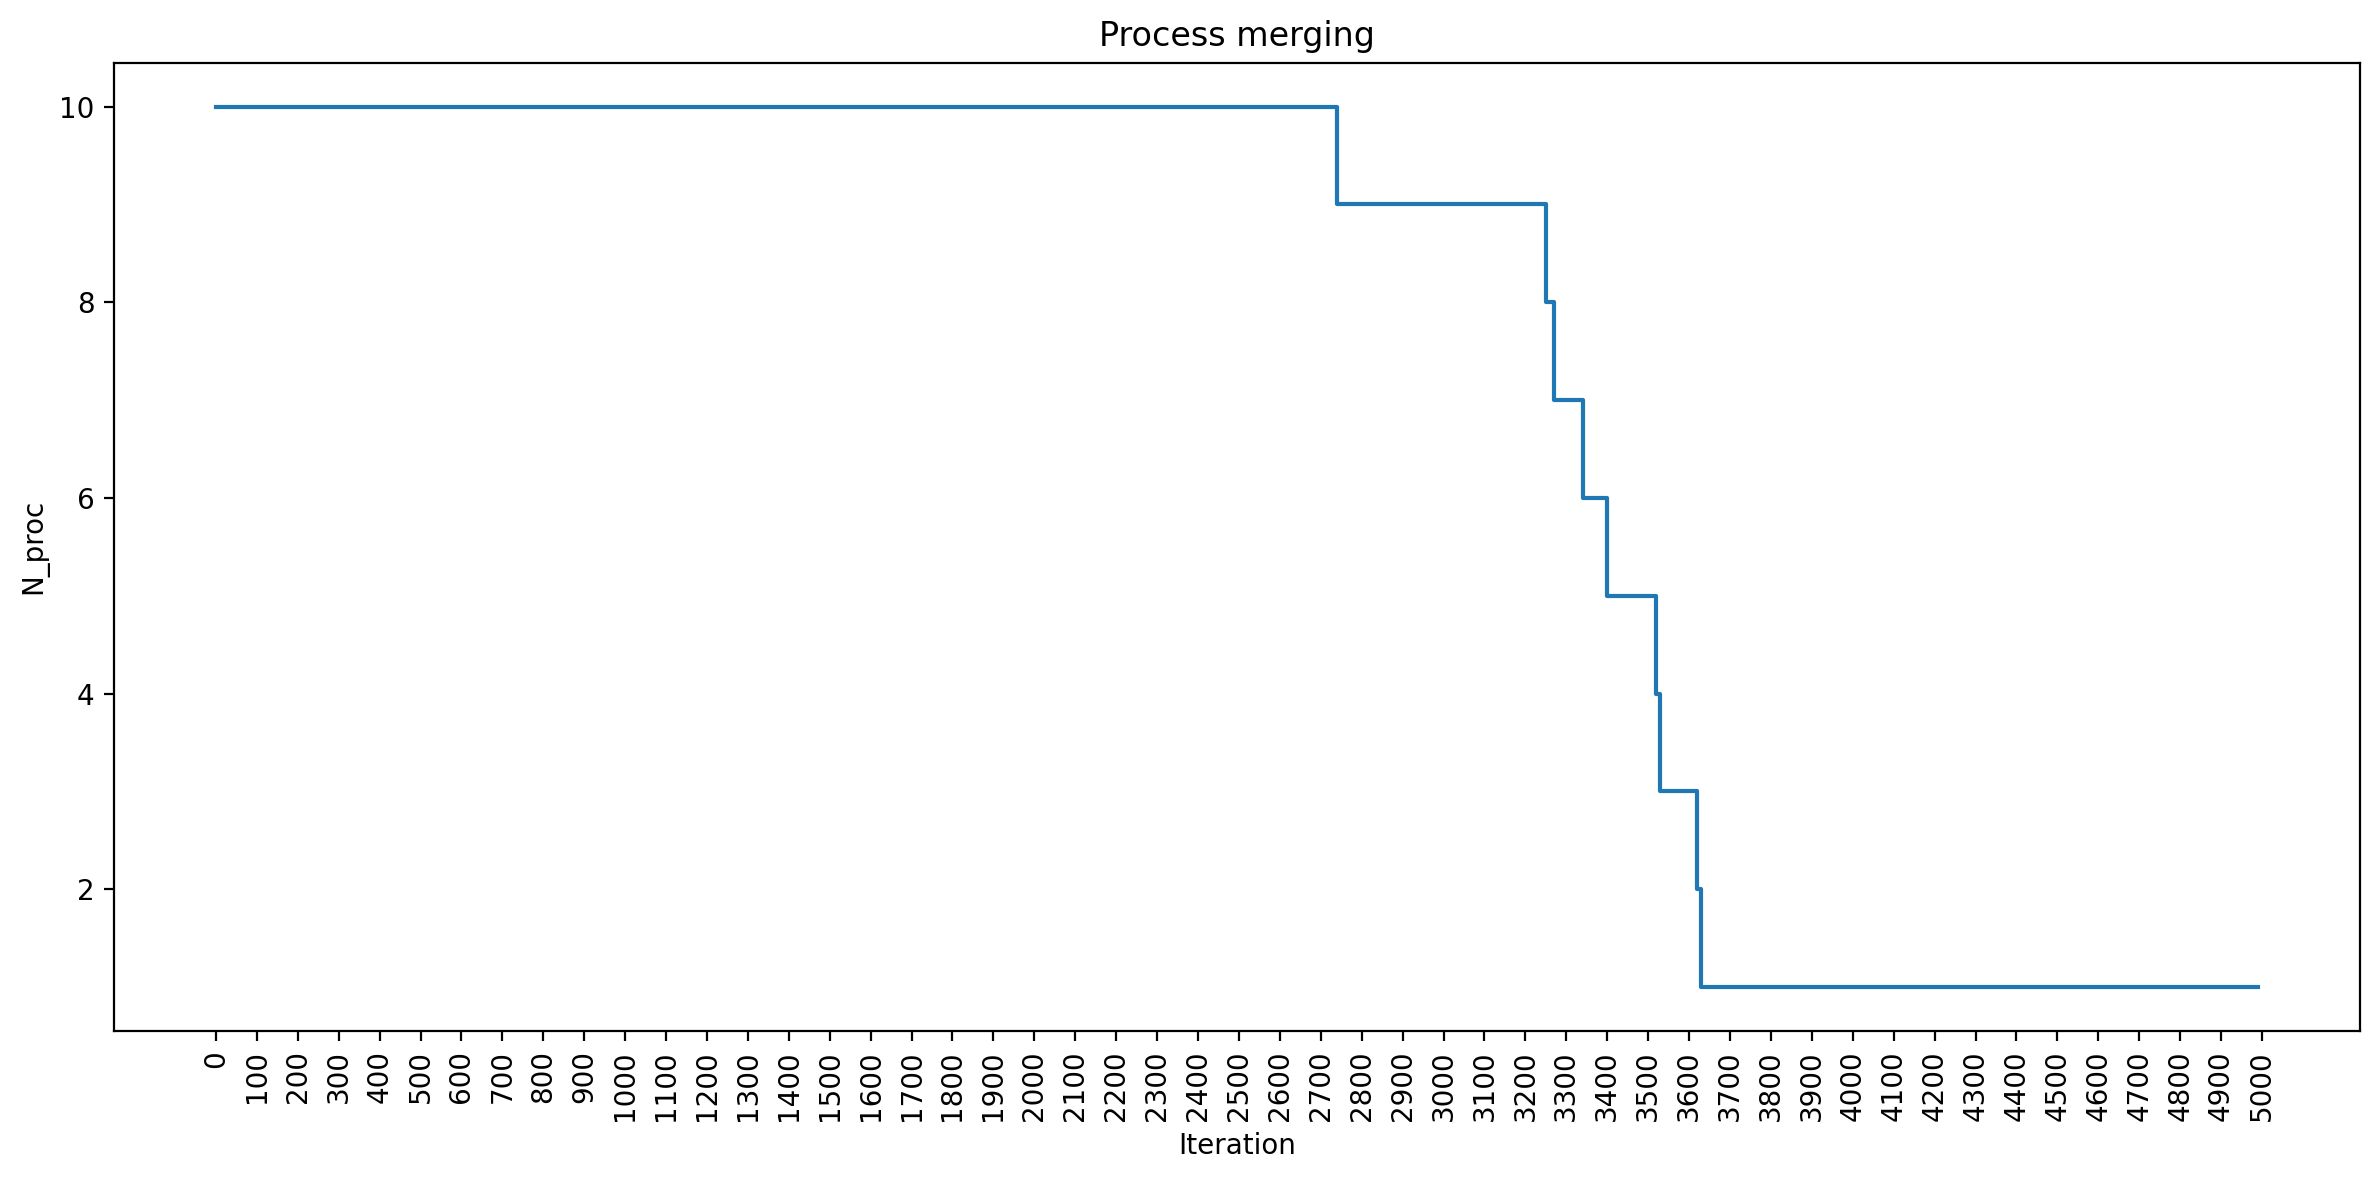

In [18]:
plt.figure(figsize=(12, 6), dpi=200)
plt.step(iters, nprocs, where='post')
plt.xlabel('Iteration')
plt.ylabel('N_proc')
plt.title('Process merging')

plt.xticks(range(0, max(iters) + 100, 100), rotation=90)

plt.tight_layout()
plt.show()

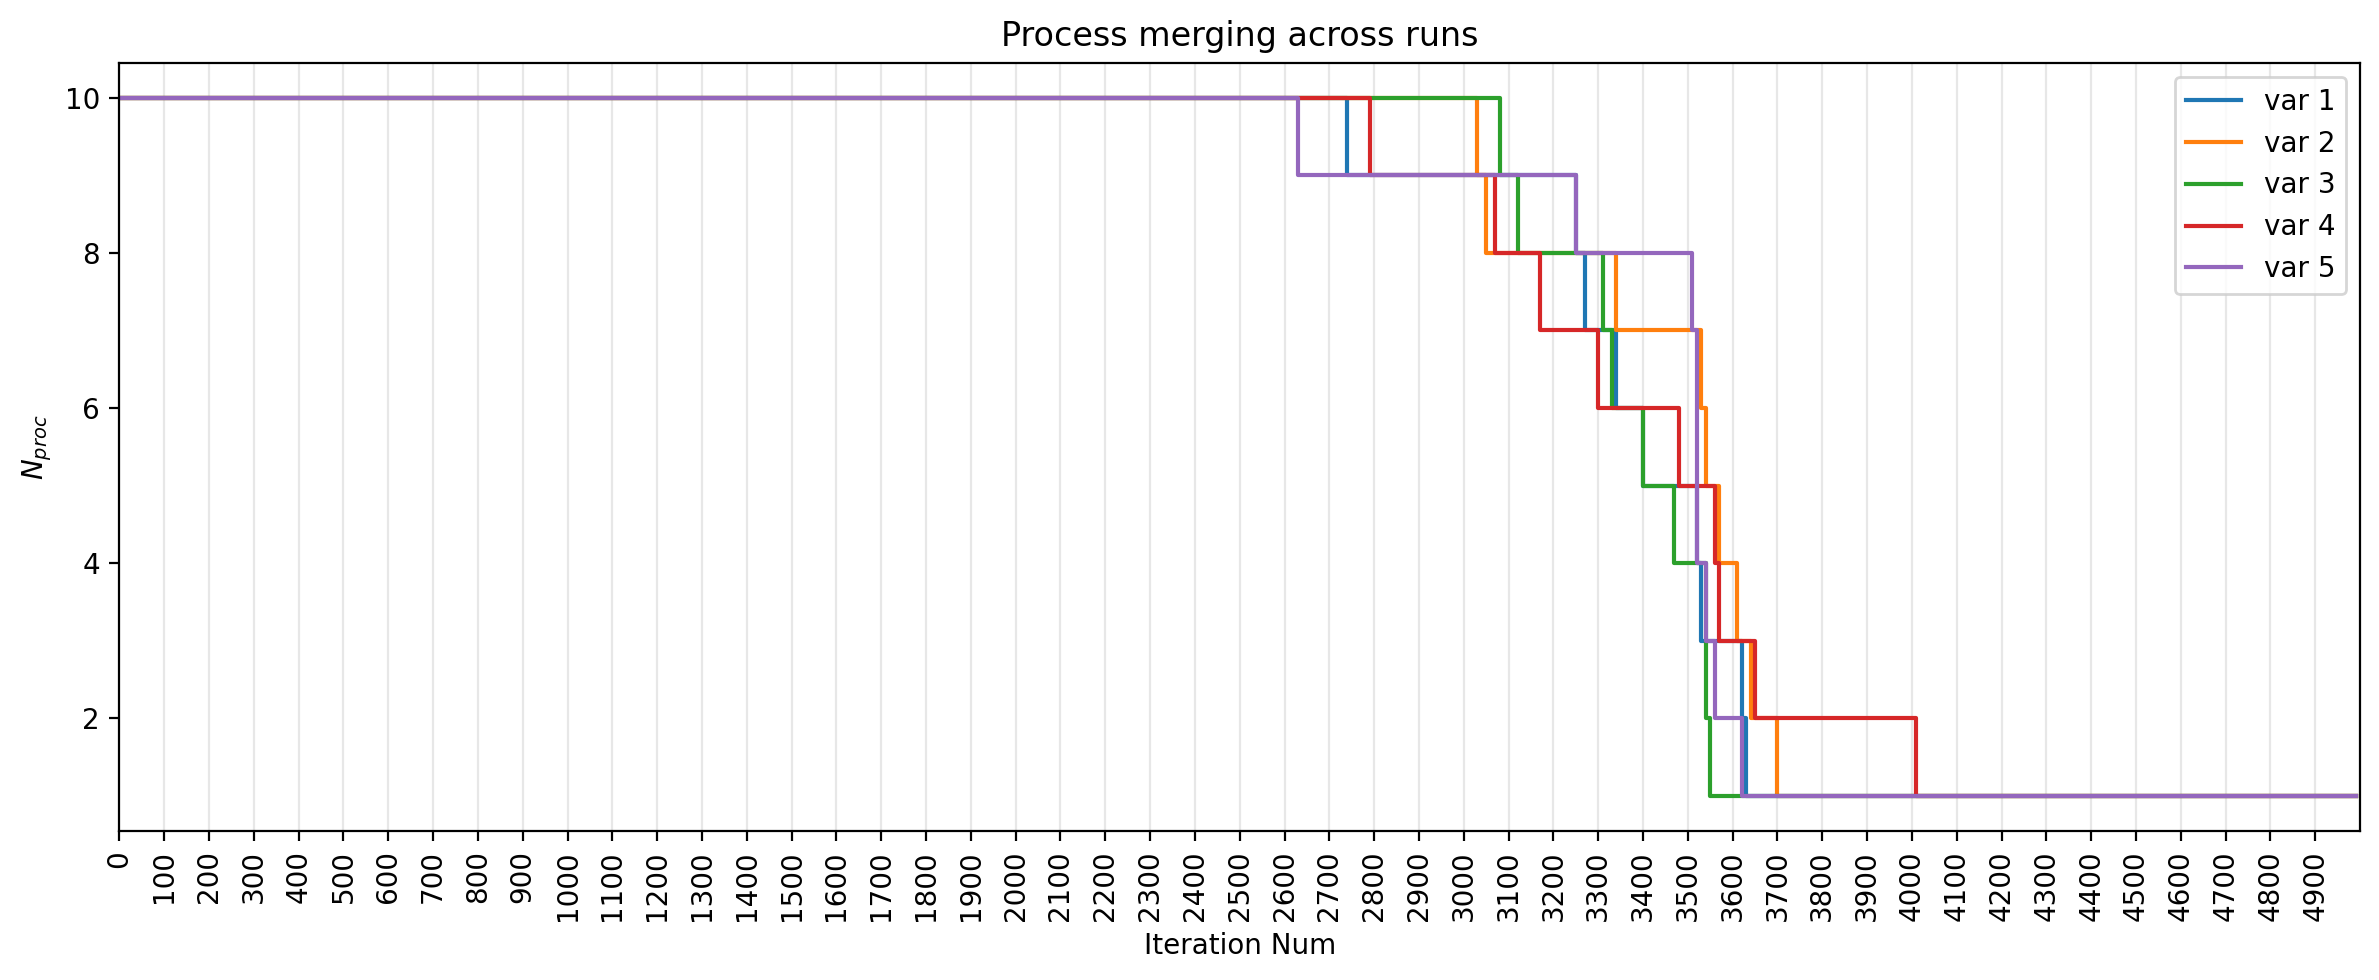

In [19]:
files = {          
    'var 1': dir_work+ 'search/logs/int_3mth_snr32_7.err',                                                                                                                    
    'var 2':  dir_work+'search/logs/int_3mth_snr32_8.err',
    'var 3':  dir_work+'search/logs/int_3mth_snr32_9.err',
    'var 4':  dir_work+'search/logs/int_3mth_snr32_10.err',
    'var 5':  dir_work+'search/logs/int_3mth_snr32_11.err',
}                                                                                                                                                                                  
                                                                                                                                                                                    
fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

for label, path in files.items():
    with open(path) as f:
        content = f.read()

    iters, nprocs = [], []
    seen = set()
    for seg in content.replace('\r', '\n').split('\n'):
        m = re.search(r'n_proc:\s*(\d+).*?\|\s*(\d+)/\d+', seg)
        if m:
            np_ = int(m.group(1))
            it  = int(m.group(2))
            if it not in seen:
                seen.add(it)
                iters.append(it)
                nprocs.append(np_)

    ax.step(iters, nprocs, where='post', label=label)

ax.set_xlabel('Iteration Num')
ax.set_ylabel(r'$N_{proc}$')
ax.set_title('Process merging across runs')
ax.set_xlim(0, 5000)
ax.set_xticks(range(0, 5000, 100))
ax.tick_params(axis='x', rotation=90)
ax.grid(True, axis='x', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# corner plot

In [20]:
runs = {        
    'var 1': savepath+'int_3mth_snr32_7/sampler_state.pkl',                                                                                         
    'var 2': savepath+'int_3mth_snr32_8/sampler_state.pkl',                                                                                                                                                                                   
    'var 3': savepath+'int_3mth_snr32_9/sampler_state.pkl',                                                                                                                                                                                   
    'var 4': savepath+'int_3mth_snr32_10/sampler_state.pkl',                                                                                                                                                                                   
    'var 5': savepath+'int_3mth_snr32_11/sampler_state.pkl',                                                                                                                                                                                   
                                                                                                                           
}      


In [21]:
TRUNC = 4000                                                                                                                                                                       
results = {}    

for name, path in runs.items():
    s = parismc.Sampler.load_state(path)
    pts  = s.searched_points_list[0][:TRUNC]
    lds  = s.searched_log_densities_list[0][:TRUNC]
    maxpt = prior_transform(pts[np.argmax(lds)].reshape(1, -1))
    maxld = log_density(maxpt)
    startpt = prior_transform(pts[0].reshape(1, -1))[0]
    results[name] = {'phys': maxpt[0], 'logden': maxld[0], 'start': startpt}
    print(f"{name}: logden={maxld[0]:.4f}  maxpt={maxpt[0]}  start={startpt}")
    # keep paris_4_seed

var 1: logden=2.8920  maxpt=[6.029002   1.12185058 0.68339176 9.10081614 0.31786578]  start=[6.0300424  1.1213525  0.67898457 9.119189   0.3191093 ]
var 2: logden=2.9440  maxpt=[6.02770973 1.11882518 0.68188057 9.12351337 0.32140942]  start=[6.0300424  1.1213525  0.67898457 9.119189   0.3191093 ]
var 3: logden=2.6683  maxpt=[5.94548498 0.81539766 0.71385617 8.91873801 0.49763208]  start=[5.9474664  0.8179905  0.71805789 8.906411   0.4953041 ]
var 4: logden=2.9310  maxpt=[6.02678511 1.12058771 0.67839411 9.13700111 0.32006956]  start=[6.0300424  1.1213525  0.67898457 9.119189   0.3191093 ]
var 5: logden=2.9158  maxpt=[6.02683829 1.12118396 0.67857259 9.12603423 0.3186309 ]  start=[6.0300424  1.1213525  0.67898457 9.119189   0.3191093 ]


In [22]:
# # Load chosen LHS point                
# filepath_lhs= dir_scratch+'lhs/lhs_snr32_1e5.pkl'                                                                                                                                
# with open(filepath_lhs, 'rb') as f:                                                                                         
#     _phys_pts, _logden = pickle.load(f)                                                                                                                                            
# lhs_best_phys = _phys_pts[np.argmax(_logden)]   

In [23]:
# Load chosen LHS point                
filepath_lhs= dir_scratch+'lhs/lhs_snr32_checkpoints/lhs_snr32_final.pkl'                                                                                                                                
with open(filepath_lhs, 'rb') as f:                                                                                         
    _phys_pts, _logden = pickle.load(f)                                                                                                                                            
lhs_best_phys = _phys_pts[np.argmax(_logden)]   

In [24]:
_logden.shape

(500000,)

In [25]:
lhs_best_phys, np.max(_logden)

(array([5.9474664 , 0.8179905 , 0.71805789, 8.906411  , 0.4953041 ]),
 np.float64(2.312361975159583))

In [26]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [27]:
import corner

In [28]:
plot_points = {name: d['phys'] for name, d in results.items()}                                                                                                                     
plot_points['LHS best'] = lhs_best_phys                                                                                                                                        
plot_points['true']     = true_params

In [29]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

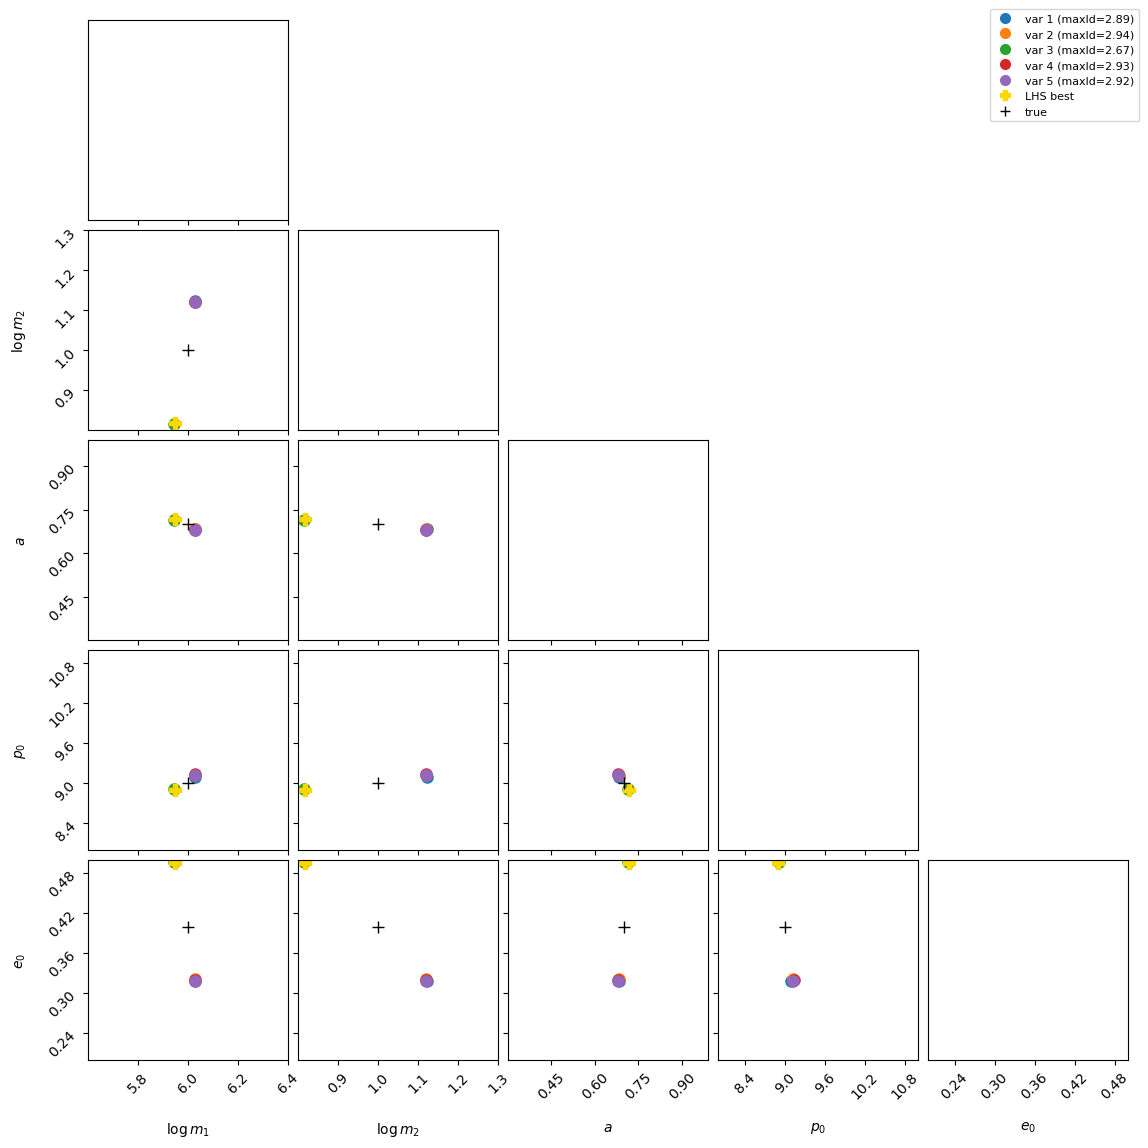

In [30]:
# Stack all points: runs + LHS best + true
all_pts = np.array([d['phys'] for d in results.values()] + [lhs_best_phys, true_params])

fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0, lw=0))
# Match colors to nproc plot: same default prop cycle, keyed by run name
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
_name_color = {name: _cycle[i % len(_cycle)] for i, name in enumerate(files)}
colors  = [_name_color.get(name, _cycle[i % len(_cycle)]) for i, name in enumerate(results)] + ['gold', 'black']
_run_markers = ['o'] * len(results)
markers = _run_markers + ['P', '+']

for (name, pt), c, mk in zip(plot_points.items(), colors, markers):
    corner.overplot_points(fig, pt.reshape(1, -1), color=c, marker=mk, ms=8)

# Re-enforce ranges after overplot_points resets them
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=c, marker=mk, ls='', ms=7,
                label=f"{name} (maxld={results[name]['logden']:.2f})" if name in results else name)
            for (name, _), c, mk in zip(plot_points.items(), colors, markers)]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=8)
# fig.suptitle('Max-ld point per run [:3900] | LHS best | true', fontsize=10)
# plt.savefig('corner_maxld_trunc3900.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
print(list(results.keys()))


['var 1', 'var 2', 'var 3', 'var 4', 'var 5']


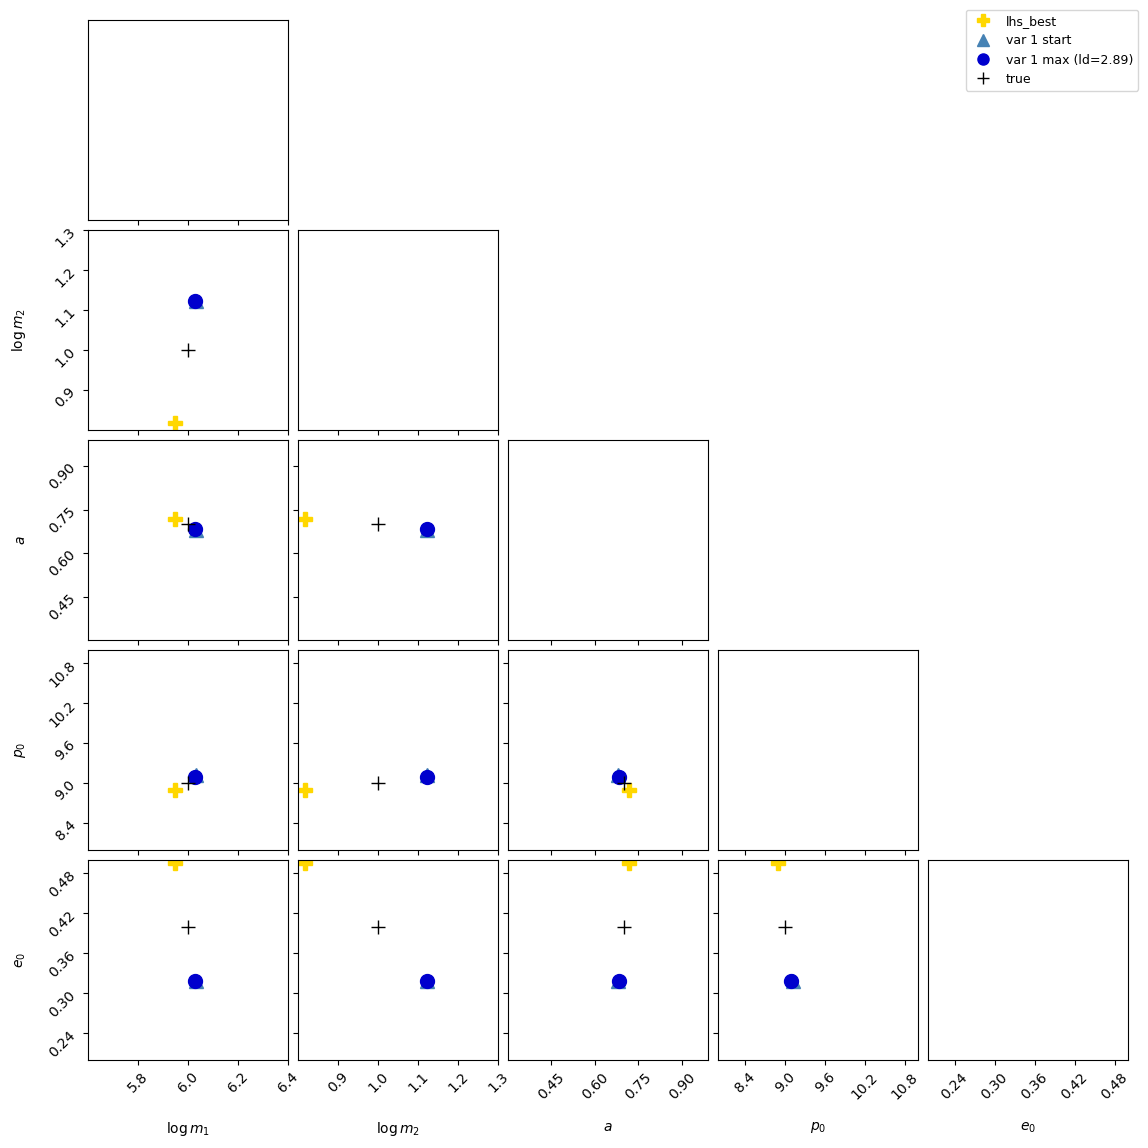

In [32]:
paris_key = 'var 1'

plot_points_init = {
    'lhs_best':           lhs_best_phys,
    f'{paris_key} start': results[paris_key]['start'],
    f'{paris_key} max':   results[paris_key]['phys'],
    'true':               true_params,
}
colors_init  = ['gold', 'steelblue', 'mediumblue', 'black']
markers_init = ['P', '^', 'o', '+']
mlds_init    = [None, None, results[paris_key]['logden'], None]

lo = np.array([r[0] for r in ranges])
hi = np.array([r[1] for r in ranges])
all_pts_padded = np.vstack([np.array(list(plot_points_init.values())), lo, hi])

fig2 = corner.corner(all_pts_padded, labels=labels, show_titles=False,
                     plot_datapoints=False, plot_density=False,
                     plot_contours=False, ranges=ranges,
                     hist_kwargs=dict(alpha=0, lw=0))

for (name, pt), c, mk in zip(plot_points_init.items(), colors_init, markers_init):
    corner.overplot_points(fig2, pt.reshape(1, -1), color=c, marker=mk, ms=10)

axes2 = np.array(fig2.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes2[row, col].set_xlim(ranges[col])
        if col < row:
            axes2[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
handles2 = [Line2D([0],[0], color=c, marker=mk, ls='', ms=8,
                   label=f"{name} (ld={ld:.2f})" if ld else name)
            for (name, _), c, mk, ld in zip(plot_points_init.items(), colors_init, markers_init, mlds_init)]
fig2.legend(handles=handles2, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=9)
plt.show()

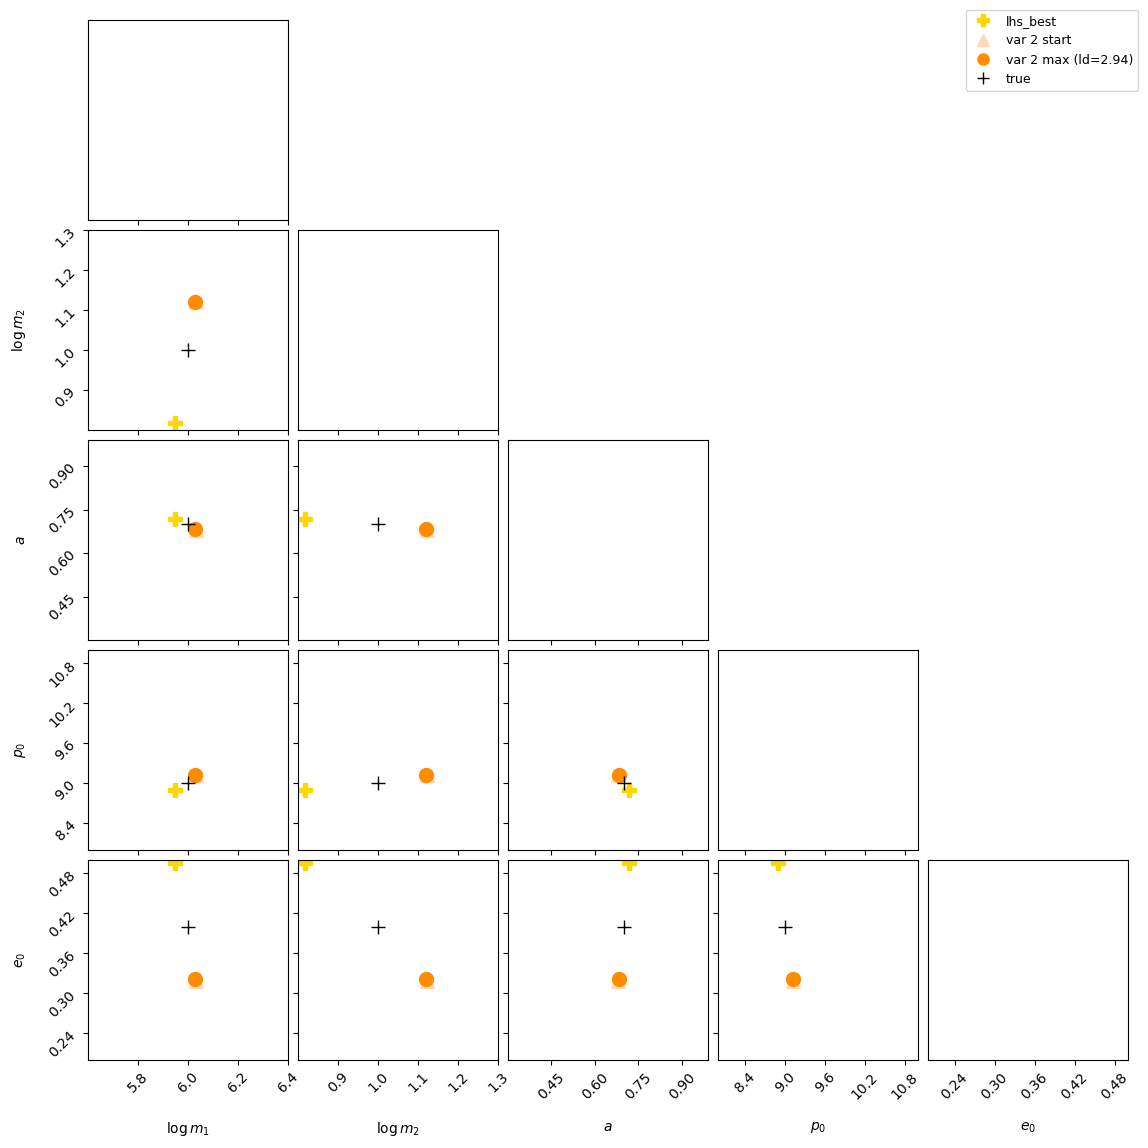

In [33]:
paris_key = 'var 2'

plot_points_init = {
    'lhs_best':           lhs_best_phys,
    f'{paris_key} start': results[paris_key]['start'],
    f'{paris_key} max':   results[paris_key]['phys'],
    'true':               true_params,
}
colors_init  = ['gold', 'peachpuff', 'darkorange', 'black']
markers_init = ['P', '^', 'o', '+']
mlds_init    = [None, None, results[paris_key]['logden'], None]

lo = np.array([r[0] for r in ranges])
hi = np.array([r[1] for r in ranges])
all_pts_padded = np.vstack([np.array(list(plot_points_init.values())), lo, hi])

fig2 = corner.corner(all_pts_padded, labels=labels, show_titles=False,
                     plot_datapoints=False, plot_density=False,
                     plot_contours=False, ranges=ranges,
                     hist_kwargs=dict(alpha=0, lw=0))

for (name, pt), c, mk in zip(plot_points_init.items(), colors_init, markers_init):
    corner.overplot_points(fig2, pt.reshape(1, -1), color=c, marker=mk, ms=10)

axes2 = np.array(fig2.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes2[row, col].set_xlim(ranges[col])
        if col < row:
            axes2[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
handles2 = [Line2D([0],[0], color=c, marker=mk, ls='', ms=8,
                   label=f"{name} (ld={ld:.2f})" if ld else name)
            for (name, _), c, mk, ld in zip(plot_points_init.items(), colors_init, markers_init, mlds_init)]
fig2.legend(handles=handles2, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=9)
plt.show()

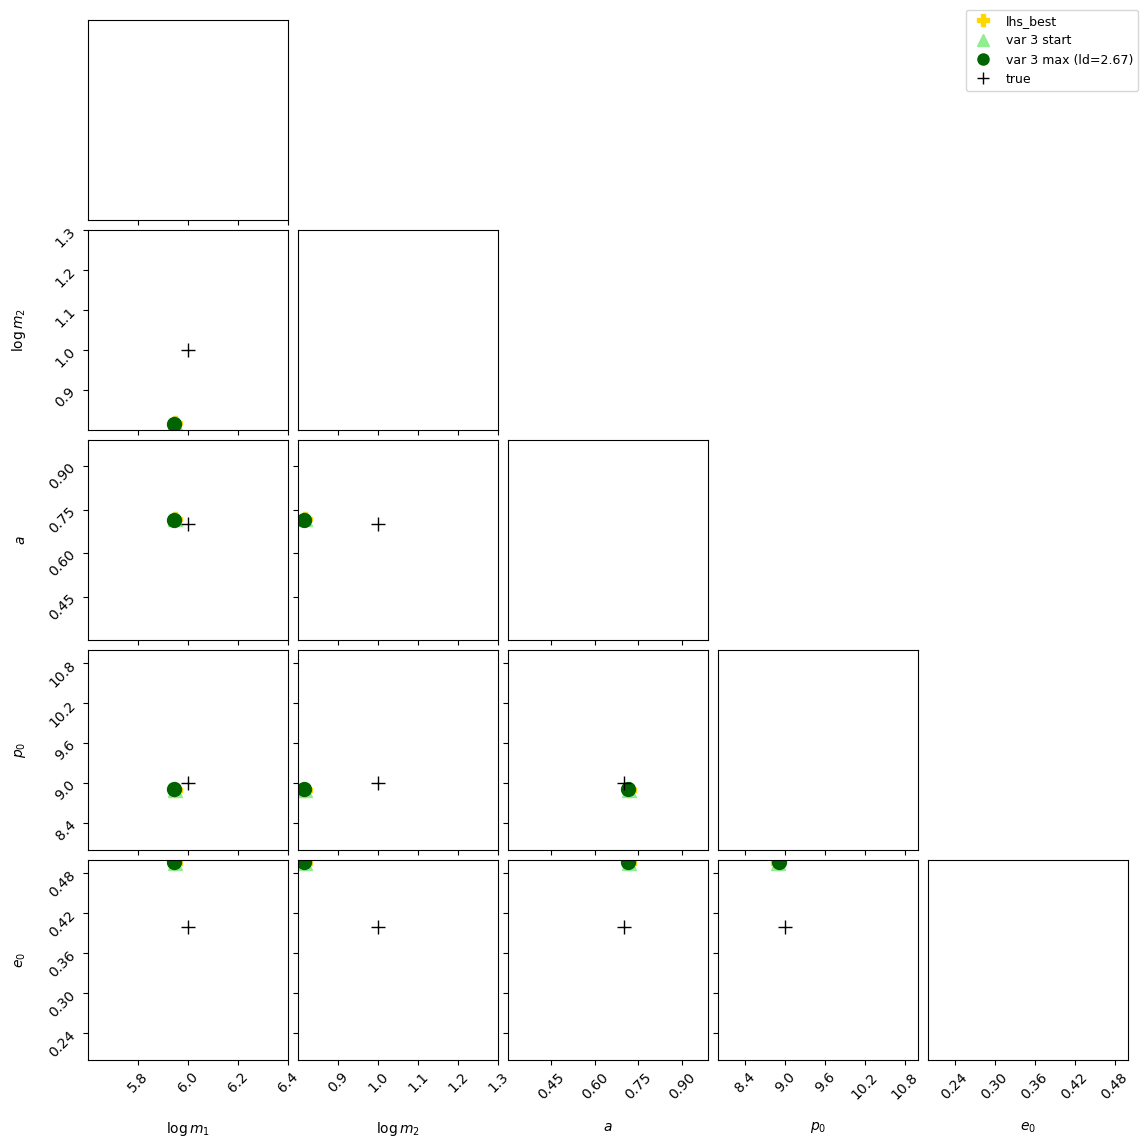

In [34]:
paris_key = 'var 3'

plot_points_init = {
    'lhs_best':           lhs_best_phys,
    f'{paris_key} start': results[paris_key]['start'],
    f'{paris_key} max':   results[paris_key]['phys'],
    'true':               true_params,
}
colors_init  = ['gold', 'lightgreen', 'darkgreen','black']
markers_init = ['P', '^', 'o', '+']
mlds_init    = [None, None, results[paris_key]['logden'], None]

lo = np.array([r[0] for r in ranges])
hi = np.array([r[1] for r in ranges])
all_pts_padded = np.vstack([np.array(list(plot_points_init.values())), lo, hi])

fig2 = corner.corner(all_pts_padded, labels=labels, show_titles=False,
                     plot_datapoints=False, plot_density=False,
                     plot_contours=False, ranges=ranges,
                     hist_kwargs=dict(alpha=0, lw=0))

for (name, pt), c, mk in zip(plot_points_init.items(), colors_init, markers_init):
    corner.overplot_points(fig2, pt.reshape(1, -1), color=c, marker=mk, ms=10)

axes2 = np.array(fig2.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes2[row, col].set_xlim(ranges[col])
        if col < row:
            axes2[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
handles2 = [Line2D([0],[0], color=c, marker=mk, ls='', ms=8,
                   label=f"{name} (ld={ld:.2f})" if ld else name)
            for (name, _), c, mk, ld in zip(plot_points_init.items(), colors_init, markers_init, mlds_init)]
fig2.legend(handles=handles2, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=9)
plt.show()

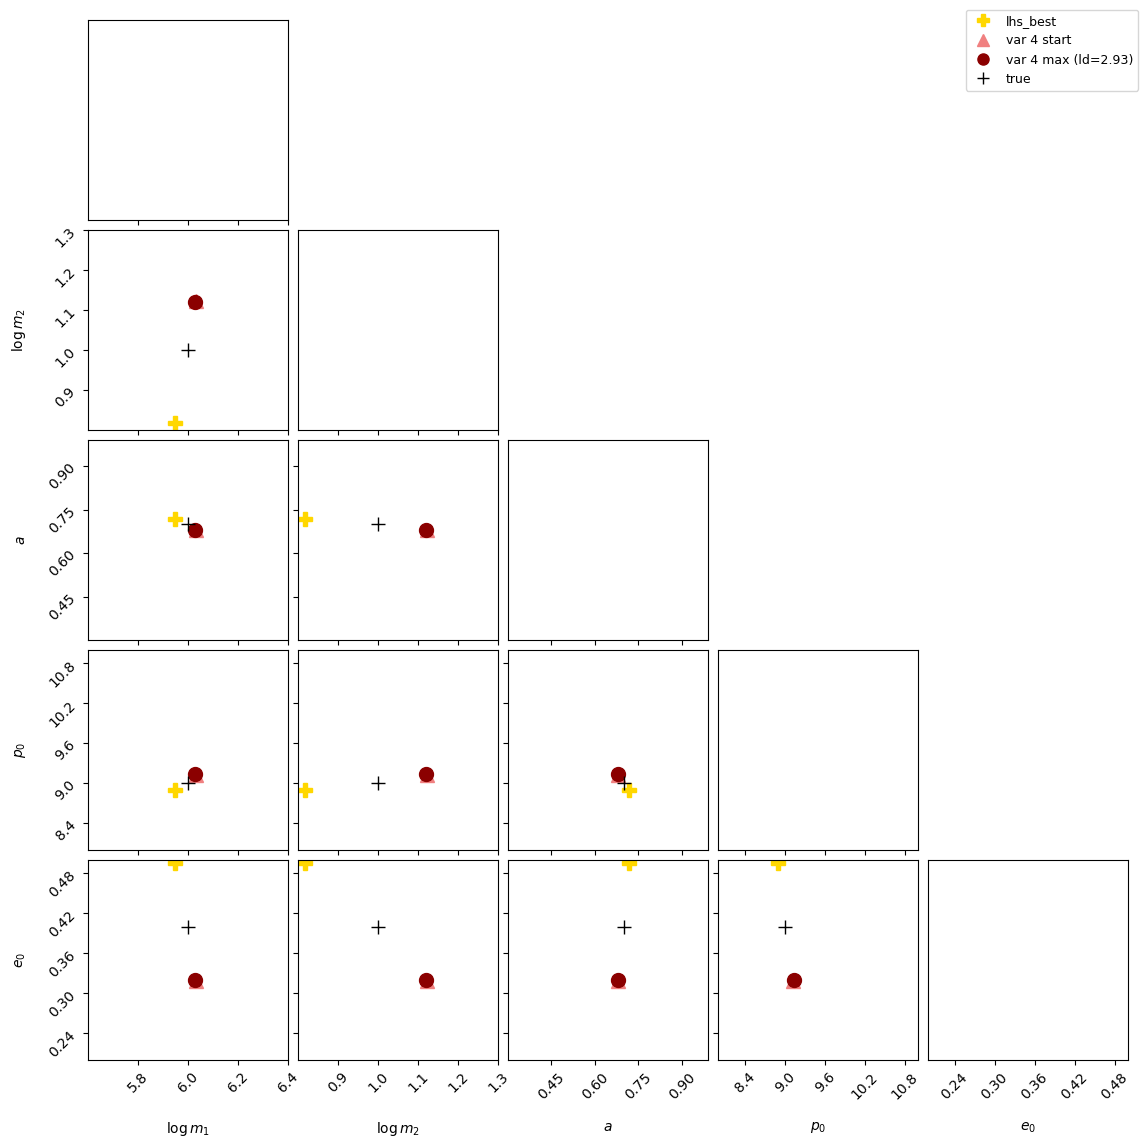

In [35]:
paris_key = 'var 4'

plot_points_init = {
    'lhs_best':           lhs_best_phys,
    f'{paris_key} start': results[paris_key]['start'],
    f'{paris_key} max':   results[paris_key]['phys'],
    'true':               true_params,
}
colors_init  = ['gold', 'lightcoral', 'darkred','black']
markers_init = ['P', '^', 'o', '+']
mlds_init    = [None, None, results[paris_key]['logden'], None]

lo = np.array([r[0] for r in ranges])
hi = np.array([r[1] for r in ranges])
all_pts_padded = np.vstack([np.array(list(plot_points_init.values())), lo, hi])

fig2 = corner.corner(all_pts_padded, labels=labels, show_titles=False,
                     plot_datapoints=False, plot_density=False,
                     plot_contours=False, ranges=ranges,
                     hist_kwargs=dict(alpha=0, lw=0))

for (name, pt), c, mk in zip(plot_points_init.items(), colors_init, markers_init):
    corner.overplot_points(fig2, pt.reshape(1, -1), color=c, marker=mk, ms=10)

axes2 = np.array(fig2.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes2[row, col].set_xlim(ranges[col])
        if col < row:
            axes2[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
handles2 = [Line2D([0],[0], color=c, marker=mk, ls='', ms=8,
                   label=f"{name} (ld={ld:.2f})" if ld else name)
            for (name, _), c, mk, ld in zip(plot_points_init.items(), colors_init, markers_init, mlds_init)]
fig2.legend(handles=handles2, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=9)
plt.show()

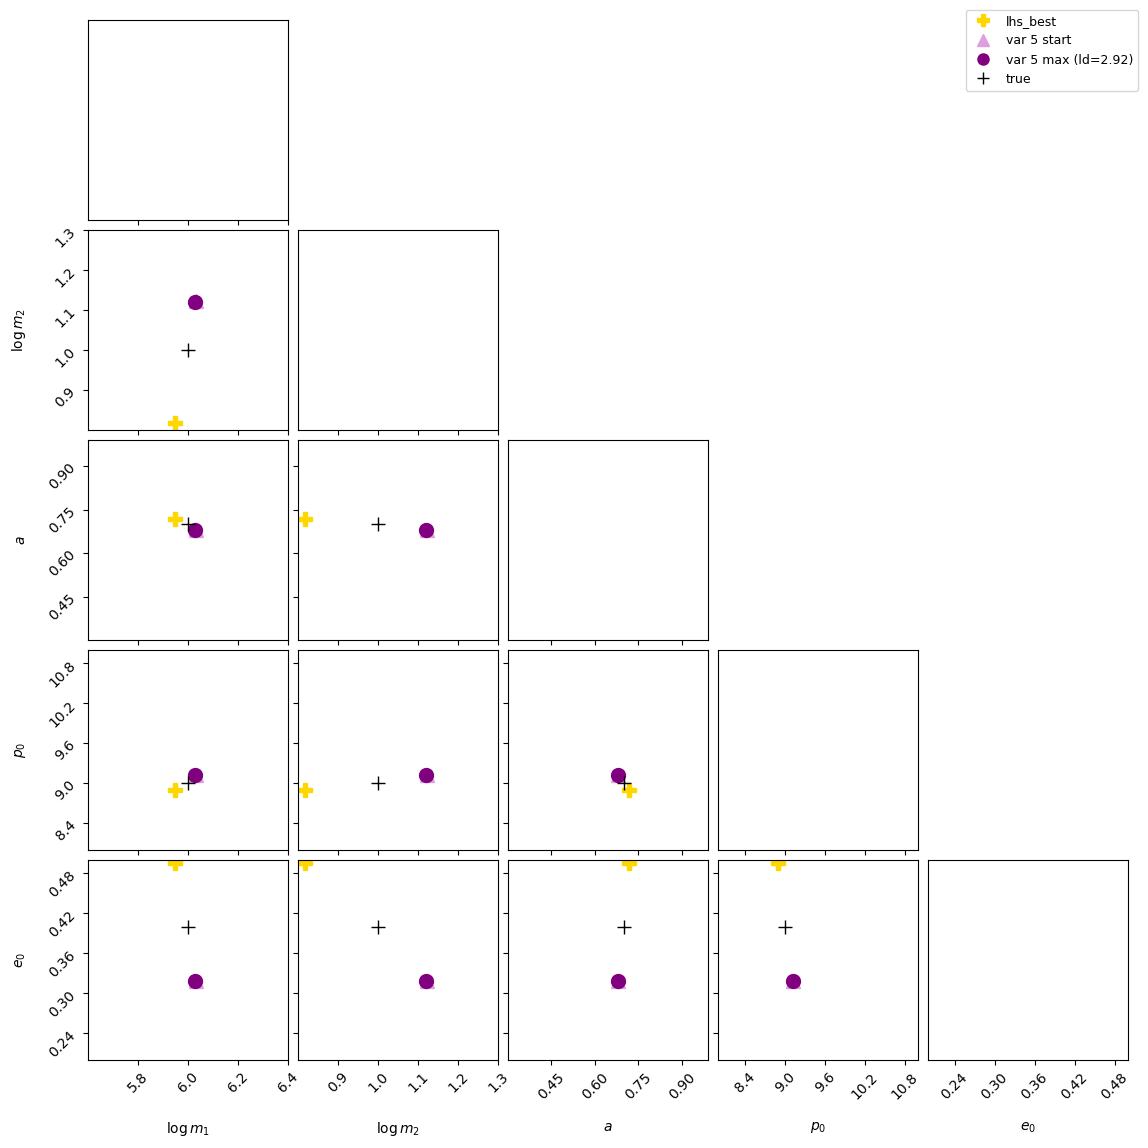

In [36]:
paris_key = 'var 5'

plot_points_init = {
    'lhs_best':           lhs_best_phys,
    f'{paris_key} start': results[paris_key]['start'],
    f'{paris_key} max':   results[paris_key]['phys'],
    'true':               true_params,
}
colors_init  = ['gold', 'plum', 'purple','black']
markers_init = ['P', '^', 'o', '+']
mlds_init    = [None, None, results[paris_key]['logden'], None]

lo = np.array([r[0] for r in ranges])
hi = np.array([r[1] for r in ranges])
all_pts_padded = np.vstack([np.array(list(plot_points_init.values())), lo, hi])

fig2 = corner.corner(all_pts_padded, labels=labels, show_titles=False,
                     plot_datapoints=False, plot_density=False,
                     plot_contours=False, ranges=ranges,
                     hist_kwargs=dict(alpha=0, lw=0))

for (name, pt), c, mk in zip(plot_points_init.items(), colors_init, markers_init):
    corner.overplot_points(fig2, pt.reshape(1, -1), color=c, marker=mk, ms=10)

axes2 = np.array(fig2.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes2[row, col].set_xlim(ranges[col])
        if col < row:
            axes2[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
handles2 = [Line2D([0],[0], color=c, marker=mk, ls='', ms=8,
                   label=f"{name} (ld={ld:.2f})" if ld else name)
            for (name, _), c, mk, ld in zip(plot_points_init.items(), colors_init, markers_init, mlds_init)]
fig2.legend(handles=handles2, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=9)
plt.show()

# connection plot

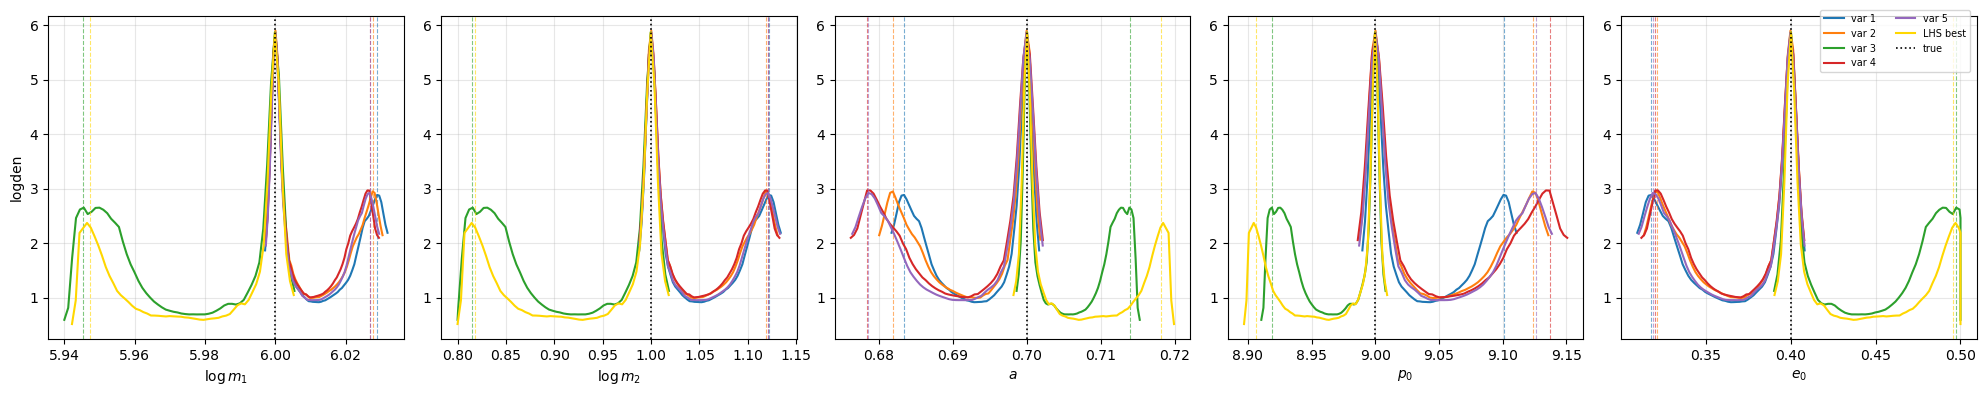

In [37]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
_name_color = {name: _cycle[i % len(_cycle)] for i, name in enumerate(files)}

N_SCAN = 60

fig, axes = plt.subplots(1, ndim, figsize=(4*ndim, 4), sharey=False)

for name, pt in plot_points.items():
    if name == 'true':
        continue
    c  = _name_color.get(name, 'gold' if name == 'LHS best' else 'black')
    mk = markers[list(plot_points.keys()).index(name)]

    direction = true_params - pt
    if np.linalg.norm(direction) == 0:
        continue

    t_vals = np.linspace(-0.1, 1.1, N_SCAN)
    line_pts = pt[np.newaxis, :] + t_vals[:, np.newaxis] * direction[np.newaxis, :]
    for dim, (lo, hi) in enumerate(ranges):
        line_pts[:, dim] = np.clip(line_pts[:, dim], lo, hi)

    lds = log_density(line_pts)

    for dim, ax in enumerate(axes):
        ax.plot(line_pts[:, dim], lds, color=c, lw=1.5,
                label=name if dim == 0 else None)
        ax.axvline(pt[dim], color=c, lw=0.8, ls='--', alpha=0.6)

for dim, ax in enumerate(axes):
    ax.axvline(true_params[dim], color='black', lw=1.2, ls=':', label='true' if dim == 0 else None)
    ax.set_xlabel(labels[dim], fontsize=10)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('logden', fontsize=10)
fig.legend(*axes[0].get_legend_handles_labels(),
           loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=7, ncol=2)
# fig.suptitle('1-D log-density scan: each point → true', fontsize=11)
plt.tight_layout()
plt.show()